In [1]:
import sys
import tensorflow as tf
import wfdb

print("Đang chạy python tại:", sys.executable)
print("TensorFlow version:", tf.__version__)
print("WFDB version:", wfdb.__version__)

Đang chạy python tại: C:\Users\ADMIN\Documents\DANG_KHOA\khoa\Scripts\python.exe
TensorFlow version: 2.10.0
WFDB version: 4.3.1


In [2]:
import sys
import pandas as pd
import wfdb
from wfdb import processing
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import signal
from scipy.stats import skew
from collections import Counter
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt, resample, lfilter

print(f"Pandas version: {pd.__version__}")
print(f"WFDB version: {wfdb.__version__}")

Pandas version: 2.3.3
WFDB version: 4.3.1


In [3]:
# =============================================================================
# 1. CẤU HÌNH HỆ THỐNG & IMPORT
# =============================================================================

target_databases = ['mitdb', 'afdb']

# Map db_name -> thư mục local trên Google Drive (bạn đã tải sẵn)
DATABASE_DIRS = {
    'afdb':  r"C:\Users\ADMIN\Documents\DANG_KHOA\dataset\files",
    'mitdb': r"C:\Users\ADMIN\Documents\DANG_KHOA\dataset\mit-bih-arrhythmia-database-1.0.0",
}

# Cấu hình TinyML
TARGET_FS = 250         # Tần số mẫu mục tiêu
WINDOW_SECONDS = 10
WINDOW_SIZE = int(TARGET_FS * WINDOW_SECONDS)
STEP_SIZE = int(WINDOW_SIZE * 0.2)

# Cấu hình lọc (Quan trọng cho MCU)
LOW_CUT = 0.5
HIGH_CUT = 40.0
FILTER_ORDER = 4

# Đường dẫn
AFDB_DIR = DATABASE_DIRS['afdb'] # Lấy từ biến cấu hình cũ
SAVE_DIR = r"C:\Users\ADMIN\Documents\DANG_KHOA\processed_data_tiny" # Đổi tên folder để tránh ghi đè cái cũ

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# Mapping nhãn: Chỉ quan tâm Normal và AFIB, còn lại sẽ là -1 (Bỏ)
LABEL_MAP = {
    '(N': 0,      # Bình thường
    '(AFIB': 1,   # Rung nhĩ
}

print(f"Cấu hình: Window={WINDOW_SIZE} samples, Filter=[{LOW_CUT}-{HIGH_CUT}Hz] (Causal)")

Cấu hình: Window=2500 samples, Filter=[0.5-40.0Hz] (Causal)


In [4]:
# =============================================================================
# 2. HÀM TIỆN ÍCH (Nâng cấp: SOS Filter ổn định & Logic Mask chính xác)
# =============================================================================
from scipy.signal import resample_poly, butter, sosfilt
import pandas as pd
import numpy as np

def preprocess_signal(signal_data, original_fs):
    # 1. Resample (Polyphase)
    if original_fs != TARGET_FS:
        gcd_fs = np.gcd(int(original_fs), int(TARGET_FS))
        up = int(TARGET_FS // gcd_fs)
        down = int(original_fs // gcd_fs)
        # resample_poly tự động áp dụng antialiasing filter
        signal_data = resample_poly(signal_data, up, down)

    signal_data = signal_data - np.mean(signal_data)
    # 2. Filter: Dùng SOS (Second-Order Sections) thay vì ba (lfilter)
    # Lý do: Ở tần số thấp (0.5Hz/250Hz), bộ số 'ba' dễ gặp lỗi làm tròn với float32.
    # SOS ổn định hơn nhiều cho deployment.
    nyquist = 0.5 * TARGET_FS
    low = LOW_CUT / nyquist
    high = HIGH_CUT / nyquist

    # Thiết kế bộ lọc Bandpass
    sos = butter(FILTER_ORDER, [low, high], btype='band', output='sos')

    # Lọc Causal (giống thực tế trên MCU)
    # Lưu ý: Tín hiệu đầu ra sẽ bị méo ở đoạn đầu do trạng thái zero-state.
    # Ta sẽ cắt bỏ đoạn này ở bước sau (Cell 3).
    filtered_signal = sosfilt(sos, signal_data)

    return filtered_signal

def create_continuous_label_mask(annotation, signal_length, fs):
    # Khởi tạo mask là -1 (Ignore/Noise)
    mask = np.full(signal_length, -1, dtype=np.int8)

    ratio = TARGET_FS / fs

    # Duyệt qua các annotation rhythm
    # AFDB structure: sample[i] là điểm BẮT ĐẦU của rhythm aux_note[i]
    for i in range(len(annotation.aux_note)):
        note = annotation.aux_note[i].strip('\x00').strip()

        start_idx = annotation.sample[i]
        # Map sang tần số mới
        if fs != TARGET_FS:
            start_idx = int(start_idx * ratio)

        # Điểm kết thúc là điểm bắt đầu của rhythm tiếp theo
        if i < len(annotation.aux_note) - 1:
            end_idx = annotation.sample[i+1]
            if fs != TARGET_FS:
                end_idx = int(end_idx * ratio)
        else:
            end_idx = signal_length

        # Clip index để tránh lỗi array bound
        start_idx = max(0, min(start_idx, signal_length))
        end_idx = max(0, min(end_idx, signal_length))

        # Gán nhãn nếu nằm trong danh sách quan tâm
        if note in LABEL_MAP:
            mask[start_idx:end_idx] = LABEL_MAP[note]

    return mask

In [5]:
# =============================================================================
# 3. HÀM XỬ LÝ THEO DANH SÁCH RECORD (CẬP NHẬT: LOGGING & SAFETY)
# =============================================================================
import numpy as np
import wfdb
import os
import gc
from wfdb import processing

# Số giây cần cắt bỏ ở đầu mỗi record (Filter transient)
FILTER_SETTLE_SECONDS = 2
DROP_SAMPLES = int(FILTER_SETTLE_SECONDS * TARGET_FS)

def check_signal_loss_detailed(segment, fs, duration_threshold=0.2):
    """
    Kiểm tra mất tín hiệu chi tiết hơn:
    Nếu có bất kỳ đoạn nào dài hơn 'duration_threshold' giây mà biên độ
    thay đổi cực thấp (gần như đường thẳng), coi là mất tín hiệu cục bộ.
    """
    # Chia segment thành các đoạn nhỏ
    window_len = int(duration_threshold * fs)
    if window_len >= len(segment):
        return False

    # Cách kiểm tra nhanh: Tính std trượt hoặc đơn giản là chia nhỏ
    # Ở đây ta chia thành các chunk để tối ưu tốc độ
    num_chunks = len(segment) // window_len
    for i in range(num_chunks):
        chunk = segment[i*window_len : (i+1)*window_len]
        # Nếu một đoạn 0.2s mà độ lệch chuẩn < 0.005 -> Flatline cục bộ
        if np.std(chunk) < 0.005:
            return True # Có lỗi
    return False

def validate_afib_quality(segment, fs):
    """
    Kiểm tra chất lượng mẫu Rung nhĩ.
    Tuy AFIB loạn nhịp, nhưng trong 10 giây bắt buộc phải có các đỉnh QRS.
    Nếu số lượng đỉnh QRS quá ít -> Tín hiệu rác/Nhiễu.
    """
    try:
        # Dùng lại xqrs_detect (nhanh và hiệu quả)
        qrs_inds = processing.xqrs_detect(sig=segment, fs=fs, verbose=False)
        
        # Một người sống, kể cả bị Rung nhĩ chậm, trong 10 giây ít nhất cũng phải đập 4-5 nhịp.
        # Nếu < 5 nhịp: Khả năng cao là nhiễu hoặc mất tín hiệu nhưng chưa chạm ngưỡng flatline.
        if len(qrs_inds) < 5:
            return False
        return True
    except:
        return False

def validate_sinus_rhythm(segment, fs):
    """
    Kiểm tra xem đoạn tín hiệu có phải là Nhịp xoang đều (Regular Sinus Rhythm) không.
    Sử dụng thuật toán XQRS (của WFDB) để tìm đỉnh R.
    """
    try:
        # 1. Tìm đỉnh R (QRS Detection)
        # qrs_inds là chỉ số mẫu (indices) của các đỉnh R
        qrs_inds = processing.xqrs_detect(sig=segment, fs=fs, verbose=False)

        # Cần ít nhất 4 đỉnh để tính toán thống kê tin cậy (3 khoảng R-R)
        if len(qrs_inds) < 4:
            return False, "Not enough beats"

        # 2. Tính khoảng R-R (đơn vị: mẫu)
        rr_intervals = np.diff(qrs_inds)

        # 3. Tính các chỉ số thống kê
        mean_rr = np.mean(rr_intervals)
        std_rr = np.std(rr_intervals)

        # --- TIÊU CHÍ 1: Độ biến thiên (Coefficient of Variation) ---
        # Nếu CV > 0.15 (15%) -> Loại (Quá thất thường)
        if mean_rr == 0: return False, "Mean RR is 0"
        cv = std_rr / mean_rr
        if cv > 0.15:
            return False, f"High Variability (CV={cv:.2f})"

        # --- TIÊU CHÍ 2: Nhịp đến sớm/muộn (Ectopic check) ---
        # Ngưỡng: 80% - 120% trung bình
        lower_bound = 0.8 * mean_rr
        upper_bound = 1.2 * mean_rr

        if np.any(rr_intervals < lower_bound) or np.any(rr_intervals > upper_bound):
            return False, "Ectopic/Irregular beats detected"

        return True, "OK"

    except Exception as e:
        # Nếu thuật toán tìm đỉnh lỗi, coi như mẫu xấu
        return False, f"QRS Detect Error: {str(e)}"

def process_dataset(record_list, dataset_name, balance=False, overlap=True):
    """
    Xử lý danh sách record và chuyển đổi sang dạng cửa sổ cho TinyML.
    """
    print(f"\n{'='*60}")
    print(f"BẮT ĐẦU XỬ LÝ TẬP: {dataset_name.upper()}")
    print(f"- Số lượng records: {len(record_list)}")
    print(f"- Danh sách records: {', '.join(record_list)}") # QUAN TRỌNG: Kiểm tra phân bố bệnh nhân
    print(f"- Balance: {balance} | Overlap: {overlap}")
    print(f"{'='*60}")

    X_temp = []
    y_temp = []

    stats = {
        'total_windows': 0,
        'skipped_noise': 0,
        'skipped_label': 0, # Bỏ qua do nhãn -1 (AFL, Noise, v.v.)
        'skipped_irregular_normal': 0, # QUAN TRỌNG: Normal bị loại do không đều
        'skipped_garbage_afib': 0,     # AFIB rác
        'unmapped_notes': set()
    }

    # Xác định bước nhảy
    current_step = STEP_SIZE if overlap else WINDOW_SIZE

    for rec_name in record_list:
        path = os.path.join(AFDB_DIR, rec_name)
        if not (os.path.exists(path + '.hea') and (os.path.exists(path + '.dat'))):
            continue

        try:
            # Chỉ đọc kênh 0
            record = wfdb.rdrecord(path, channels=[0])
            # Đọc annotation
            annotation = wfdb.rdann(path, 'atr')

            # Tracking các nhãn lạ để debug
            for note in annotation.aux_note:
                clean_note = note.strip('\x00').strip()
                if clean_note not in LABEL_MAP:
                    stats['unmapped_notes'].add(clean_note)

            raw_sig = record.p_signal[:, 0]

            # 1. Preprocess (Filter SOS)
            clean_sig = preprocess_signal(raw_sig, record.fs)

            # 2. Tạo Mask nhãn
            safe_len = len(clean_sig)
            full_mask = create_continuous_label_mask(annotation, safe_len, record.fs)

            # 3. Transient Removal
            if safe_len > (DROP_SAMPLES + WINDOW_SIZE):
                clean_sig = clean_sig[DROP_SAMPLES:]
                full_mask = full_mask[DROP_SAMPLES:]
            else:
                continue

            # 4. Cắt cửa sổ (Sliding Window)
            current_len = len(clean_sig)
            num_windows = (current_len - WINDOW_SIZE) // current_step

            for i in range(num_windows):
                start = i * current_step
                end = start + WINDOW_SIZE

                segment = clean_sig[start:end]
                seg_label = full_mask[start:end]

                # --- KIỂM TRA CHẤT LƯỢNG TÍN HIỆU ---

                # Check 1: Nhãn không xác định (Mask -1)
                # (Ví dụ: đoạn chuyển tiếp Rung nhĩ -> Cuồng nhĩ mà ta không map Cuồng nhĩ)
                if np.any(seg_label == -1):
                    stats['skipped_label'] += 1
                    continue

                # Check 2: Flatline (Mất tín hiệu)
                # Toàn cục
                seg_std = np.std(segment)
                if seg_std < 0.005:
                    stats['skipped_noise'] += 1
                    continue
                # Cục bộ (Detailed check)
                if check_signal_loss_detailed(segment, record.fs):
                    stats['skipped_noise'] += 1
                    continue

                # Check 3: Saturation (Vượt ngưỡng 5mV)
                if np.max(np.abs(segment)) > 5.0:
                    stats['skipped_noise'] += 1
                    continue

                # --- TINYML NORMALIZATION ---
                '''
                seg_mean = np.mean(segment)
                eps = 1e-7
                # Z-score normalization
                normalized_segment = (segment - seg_mean) / (seg_std + eps)
                # Hard Clip cho Int8 Quantization optimization
                normalized_segment = np.clip(normalized_segment, -5.0, 5.0)
                '''

                seg_mean = np.mean(segment)
                noise_floor = 0.05 
                divisor = max(seg_std, noise_floor)             
                normalized_segment = (segment - seg_mean) / divisor
                # Clip cứng để đưa vào phạm vi [-5, 5] (hoặc [-4, 4] tùy thích)
                # Giúp lượng tử hóa (Quantization) int8 sau này hiệu quả hơn
                normalized_segment = np.clip(normalized_segment, -5.0, 5.0)

                # --- LABELING LOGIC ---
                afib_count = np.sum(seg_label == 1)
                normal_count = np.sum(seg_label == 0)

                final_label = -1
                # Logic nghiêm ngặt để tạo dữ liệu sạch
                if afib_count >= (0.99 * WINDOW_SIZE):
                    if validate_afib_quality(segment, record.fs):
                        final_label = 1
                    else:
                        stats['skipped_garbage_afib'] += 1 # Đếm số lượng AFIB rác bị loại
                        continue
                    
                elif normal_count >= (0.99 * WINDOW_SIZE):
                    is_clean, reason = validate_sinus_rhythm(segment, record.fs)
                    if is_clean:
                        final_label = 0
                    else:
                        stats['skipped_irregular_normal'] += 1
                        continue

                if final_label != -1:
                    X_temp.append(normalized_segment.astype(np.float32))
                    y_temp.append(final_label)
                    stats['total_windows'] += 1
                else:
                    # Cửa sổ chuyển tiếp (không đủ 90% Normal hoặc 50% AF)
                    stats['skipped_label'] += 1

        except Exception as e:
            print(f"⚠️ Lỗi xử lý {rec_name}: {e}")
            continue

    # Convert to Numpy
    if len(X_temp) == 0:
        print(f"⚠️ CẢNH BÁO: Tập {dataset_name} không tạo được dữ liệu nào!")
        return

    X_arr = np.array(X_temp, dtype=np.float32)
    y_arr = np.array(y_temp, dtype=np.int8)

    # Giải phóng bộ nhớ list tạm
    del X_temp, y_temp
    gc.collect()

    print(f"-> Thống kê thô: {len(y_arr)} windows.")
    print(f"   (Bỏ qua do Nhiễu: {stats['skipped_noise']} | Bỏ qua do Nhãn/Chuyển tiếp: {stats['skipped_label']})")
    if stats['unmapped_notes']:
        print(f"   ⚠️ Các nhãn có trong dữ liệu nhưng bị bỏ qua (không trong LABEL_MAP): {stats['unmapped_notes']}")
    print(f"   - Loại do Normal Không đều:   {stats['skipped_irregular_normal']} (Đây là số mẫu 'xấu' được lọc ra)")
    print(f"   - Loại AFIB rác (MỚI):      {stats['skipped_garbage_afib']} <--- Đã lọc được cái bạn thắc mắc")

    # --- UNDERSAMPLING (Chỉ khi balance=True) ---
    if balance:
        idx_0 = np.where(y_arr == 0)[0]
        idx_1 = np.where(y_arr == 1)[0]
        len_0, len_1 = len(idx_0), len(idx_1)

        print(f"-> Trước cân bằng: Normal={len_0}, AFIB={len_1}")

        if len_0 > 0 and len_1 > 0:
            imbalance_ratio = abs(len_0 - len_1) / max(len_0, len_1)
            # Chỉ cân bằng nếu lệch > 15%
            if imbalance_ratio >= 0.15:
                min_len = min(len_0, len_1)
                np.random.seed(42)
                idx_0_sel = np.random.choice(idx_0, min_len, replace=False)
                idx_1_sel = np.random.choice(idx_1, min_len, replace=False)

                combined_idx = np.concatenate([idx_0_sel, idx_1_sel])
                np.random.shuffle(combined_idx)

                X_arr = X_arr[combined_idx]
                y_arr = y_arr[combined_idx]
                print(f"-> Đã cân bằng xuống: {min_len} mẫu mỗi lớp.")

    # Thêm chiều channel (N, L, 1) cho CNN
    X_arr = X_arr[..., np.newaxis]

    # Lưu file
    save_path_X = os.path.join(SAVE_DIR, f'X_{dataset_name}.npy')
    save_path_y = os.path.join(SAVE_DIR, f'y_{dataset_name}.npy')
    np.save(save_path_X, X_arr)
    np.save(save_path_y, y_arr)

    print(f"✅ HOÀN TẤT {dataset_name}: X shape {X_arr.shape}, y shape {y_arr.shape}")


In [6]:
# =============================================================================
# 4. CHIA DỮ LIỆU THỦ CÔNG (REVISED STRATEGY: HEAVY TRAIN)
# =============================================================================

# CHIẾN LƯỢC MỚI: Dồn sự đa dạng vào tập Train.
# - Train: Phải chứa 3 ông lớn nhất (04043, 08219, 04936) để model thấy được mọi kiểu Rung nhĩ.
# - Val: Dùng các ca tầm trung (Medium) để đánh giá khả năng tổng quát.
# - Test: Các ca còn lại.

train_records = [
    '04043', #1
    '04936', #2
    '07162', #3
    '07859', #4
    '07879', #5
    '08455', #6
    '06426', #7
    '05121', #8
    '06995', #9
    '05261', #10
    '06453', #11
    '04015', #12
    '04908', #13
    '04048', #14
    '08434', #15
    '08378' #16
]

val_records = [
    '04746',    
    '07910',
    '08219'
]

# Danh sách tất cả file (đã loại bỏ file lỗi như code cũ)
all_files = [f.replace('.hea', '') for f in os.listdir(AFDB_DIR) if f.endswith('.hea')]
EXCLUDED_RECORDS = ['00735', '03665']
all_files = [f for f in all_files if f not in EXCLUDED_RECORDS]

all_files_set = set(all_files)
assigned_set = set(train_records + val_records)
test_records = list(all_files_set - assigned_set)

test_records.sort()

print(f"Chiến lược chia lại (Heavy Training Diversity):")
print(f"- Train: {len(train_records)} files")
print(f"- Val:   {len(val_records)} files")
print(f"- Test:  {len(test_records)} files")

# --- THỰC THI PIPELINE ---
# Lưu ý: Train vẫn giữ balance=True để không bị lấn át bởi số lượng mẫu bình thường quá lớn
process_dataset(train_records, 'train', balance=False, overlap=True)
process_dataset(val_records, 'val', balance=True, overlap=True)
process_dataset(test_records, 'test', balance=False, overlap=True)

print(f"\n🎉 TOÀN BỘ QUÁ TRÌNH HOÀN TẤT! Dữ liệu nằm tại: {SAVE_DIR}")

Chiến lược chia lại (Heavy Training Diversity):
- Train: 16 files
- Val:   3 files
- Test:  4 files

BẮT ĐẦU XỬ LÝ TẬP: TRAIN
- Số lượng records: 16
- Danh sách records: 04043, 04936, 07162, 07859, 07879, 08455, 06426, 05121, 06995, 05261, 06453, 04015, 04908, 04048, 08434, 08378
- Balance: False | Overlap: True
-> Thống kê thô: 240757 windows.
   (Bỏ qua do Nhiễu: 15848 | Bỏ qua do Nhãn/Chuyển tiếp: 4874)
   ⚠️ Các nhãn có trong dữ liệu nhưng bị bỏ qua (không trong LABEL_MAP): {'(J', '(AFL'}
   - Loại do Normal Không đều:   31187 (Đây là số mẫu 'xấu' được lọc ra)
   - Loại AFIB rác (MỚI):      53 <--- Đã lọc được cái bạn thắc mắc
✅ HOÀN TẤT train: X shape (240757, 2500, 1), y shape (240757,)

BẮT ĐẦU XỬ LÝ TẬP: VAL
- Số lượng records: 3
- Danh sách records: 04746, 07910, 08219
- Balance: True | Overlap: True
-> Thống kê thô: 40157 windows.
   (Bỏ qua do Nhiễu: 2274 | Bỏ qua do Nhãn/Chuyển tiếp: 623)
   ⚠️ Các nhãn có trong dữ liệu nhưng bị bỏ qua (không trong LABEL_MAP): {'(AFL'}
   -

In [7]:
# CELL KIỂM TRA CÂN BẰNG DỮ LIỆU
import numpy as np
import os

def check_balance(name):
    y_path = os.path.join(SAVE_DIR, f'y_{name}.npy')
    if os.path.exists(y_path):
        y = np.load(y_path)
        num_afib = np.sum(y == 1)
        num_normal = np.sum(y == 0)
        total = len(y)
        print(f"--- Tập {name.upper()} ---")
        print(f"   Tổng: {total}")
        print(f"   Rung nhĩ (1): {num_afib} ({num_afib/total*100:.2f}%)")
        print(f"   Bình thường (0): {num_normal} ({num_normal/total*100:.2f}%)")
    else:
        print(f"Chưa thấy file {name}")

check_balance('train')
check_balance('val')
check_balance('test')

--- Tập TRAIN ---
   Tổng: 240757
   Rung nhĩ (1): 107637 (44.71%)
   Bình thường (0): 133120 (55.29%)
--- Tập VAL ---
   Tổng: 32678
   Rung nhĩ (1): 16339 (50.00%)
   Bình thường (0): 16339 (50.00%)
--- Tập TEST ---
   Tổng: 62205
   Rung nhĩ (1): 28215 (45.36%)
   Bình thường (0): 33990 (54.64%)



==================== PHÂN TÍCH TẬP: TRAIN ====================
🔹 Kích thước Input (X): (240757, 2500, 1)
🔹 Kích thước Label (y): (240757,)
🔹 Phân bố nhãn: {0: 133120, 1: 107637}
   - Bình thường (0): 133120 mẫu
   - Rung nhĩ (1):    107637 mẫu

Dang vẽ biểu đồ ngẫu nhiên... (Chạy lại Cell này để xem các mẫu khác)


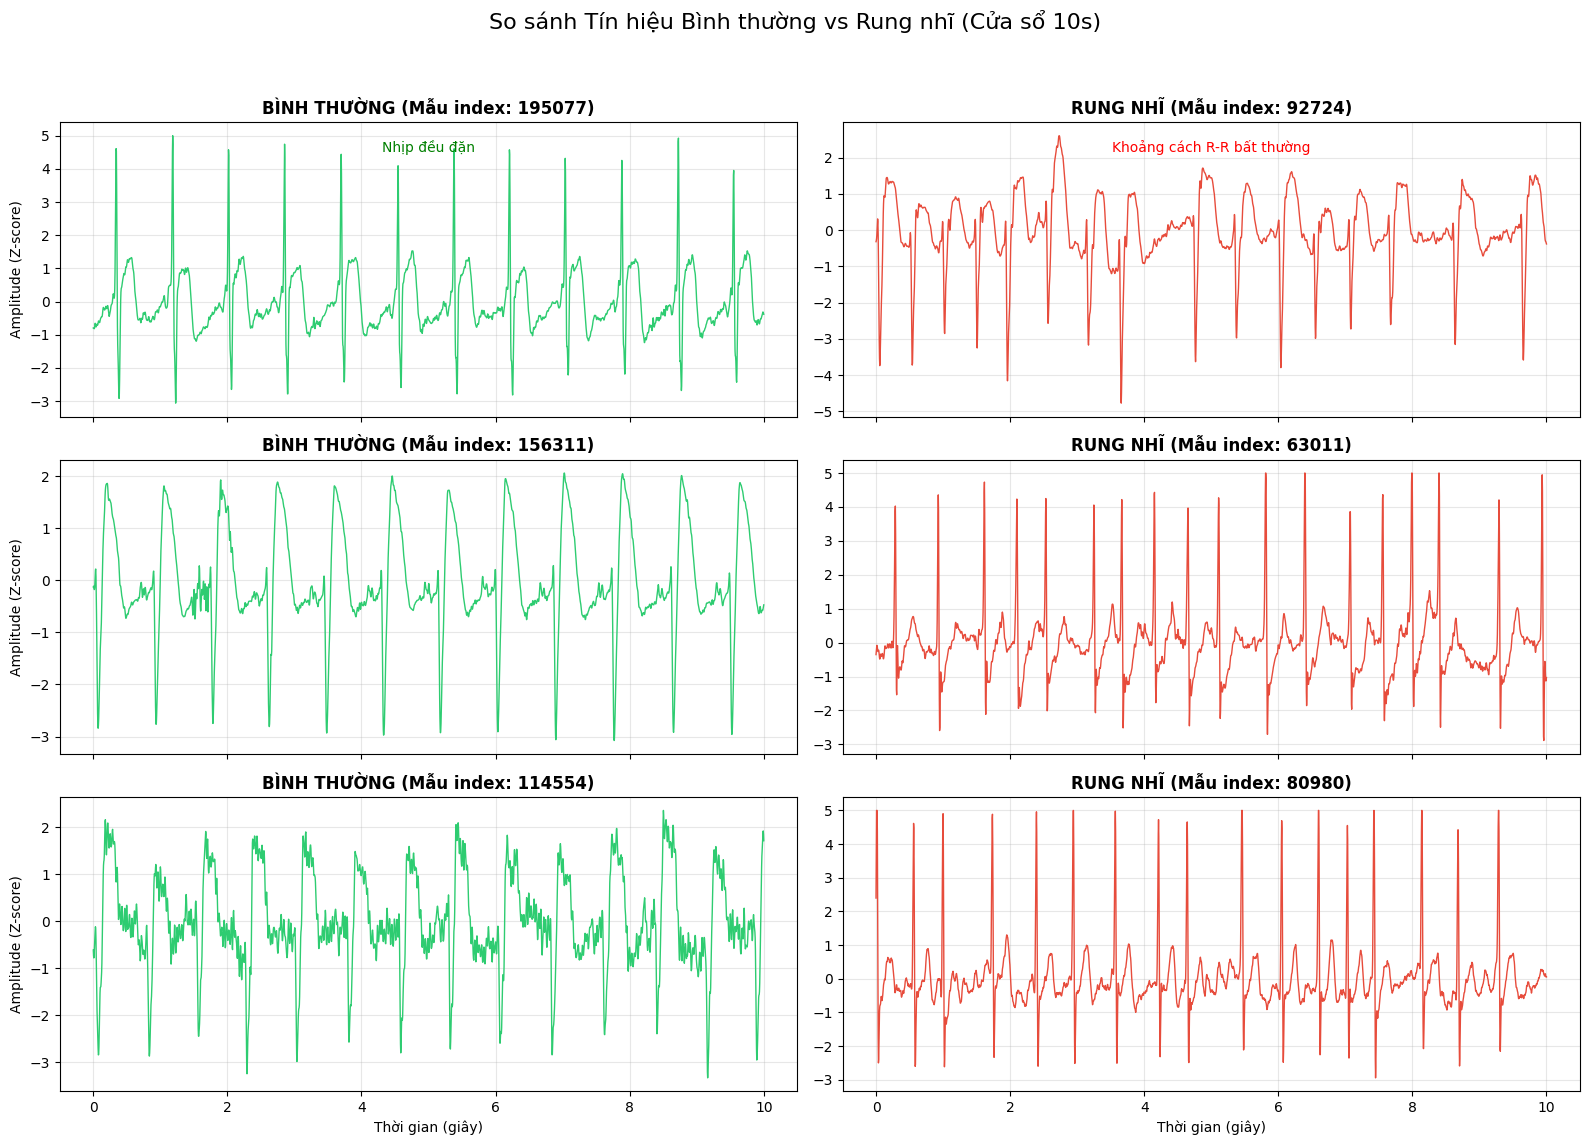

In [4]:
# =============================================================================
# 5. PHÂN TÍCH & TRỰC QUAN HÓA DỮ LIỆU SAU KHI XỬ LÝ
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import os

def load_and_analyze(dataset_name):
    print(f"\n{'='*20} PHÂN TÍCH TẬP: {dataset_name.upper()} {'='*20}")

    # Load dữ liệu
    x_path = os.path.join(SAVE_DIR, f'X_{dataset_name}.npy')
    y_path = os.path.join(SAVE_DIR, f'y_{dataset_name}.npy')

    if not os.path.exists(x_path) or not os.path.exists(y_path):
        print(f"❌ Không tìm thấy file cho tập {dataset_name}")
        return None, None

    X = np.load(x_path)
    y = np.load(y_path)

    # 1. Kiểm tra kích thước
    print(f"🔹 Kích thước Input (X): {X.shape}") # Mong đợi: (Số lượng, 2500, 1)
    print(f"🔹 Kích thước Label (y): {y.shape}")

    # 2. Kiểm tra cân bằng lớp
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique, counts))
    print(f"🔹 Phân bố nhãn: {dist}")
    print(f"   - Bình thường (0): {dist.get(0, 0)} mẫu")
    print(f"   - Rung nhĩ (1):    {dist.get(1, 0)} mẫu")

    return X, y

def plot_samples(X, y, num_samples=3):
    """Vẽ ngẫu nhiên các mẫu Normal và AFIB để so sánh"""

    # Tách chỉ số các lớp
    idx_normal = np.where(y == 0)[0]
    idx_afib = np.where(y == 1)[0]

    # Trục thời gian (giây)
    time_axis = np.linspace(0, WINDOW_SECONDS, X.shape[1])

    fig, axes = plt.subplots(num_samples, 2, figsize=(16, 4*num_samples), sharex=True)
    fig.suptitle(f'So sánh Tín hiệu Bình thường vs Rung nhĩ (Cửa sổ {WINDOW_SECONDS}s)', fontsize=16)

    # Chọn ngẫu nhiên
    rng = np.random.default_rng()
    sample_normals = rng.choice(idx_normal, num_samples, replace=False)
    sample_afibs = rng.choice(idx_afib, num_samples, replace=False)

    for i in range(num_samples):
        # --- Plot Normal ---
        ax_norm = axes[i, 0]
        sig_norm = X[sample_normals[i]].squeeze() # Bỏ chiều cuối (2500, 1) -> (2500,)
        ax_norm.plot(time_axis, sig_norm, color='#2ecc71', linewidth=1)
        ax_norm.set_title(f'BÌNH THƯỜNG (Mẫu index: {sample_normals[i]})', fontweight='bold')
        ax_norm.set_ylabel('Amplitude (Z-score)')
        ax_norm.grid(True, alpha=0.3)

        # --- Plot AFIB ---
        ax_afib = axes[i, 1]
        sig_afib = X[sample_afibs[i]].squeeze()
        ax_afib.plot(time_axis, sig_afib, color='#e74c3c', linewidth=1)
        ax_afib.set_title(f'RUNG NHĨ (Mẫu index: {sample_afibs[i]})', fontweight='bold')
        ax_afib.grid(True, alpha=0.3)

        # Đánh dấu các đỉnh R (tương đối) để thấy sự loạn nhịp
        # (Chỉ mang tính trực quan, không phải thuật toán detect chính xác)
        if i == 0:
            ax_norm.text(0.5, 0.9, "Nhịp đều đặn", transform=ax_norm.transAxes, ha='center', color='green')
            ax_afib.text(0.5, 0.9, "Khoảng cách R-R bất thường", transform=ax_afib.transAxes, ha='center', color='red')

    axes[-1, 0].set_xlabel('Thời gian (giây)')
    axes[-1, 1].set_xlabel('Thời gian (giây)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- THỰC THI ---
# 1. Load tập Train để kiểm tra
X_train, y_train = load_and_analyze('train')

# 2. Nếu load thành công, vẽ biểu đồ
if X_train is not None:
    print("\nDang vẽ biểu đồ ngẫu nhiên... (Chạy lại Cell này để xem các mẫu khác)")
    plot_samples(X_train, y_train, num_samples=3)


🔍 ĐANG KIỂM TRA CHẤT LƯỢNG TÍN HIỆU TẠI: C:\Users\ADMIN\Documents\DANG_KHOA\dataset\files


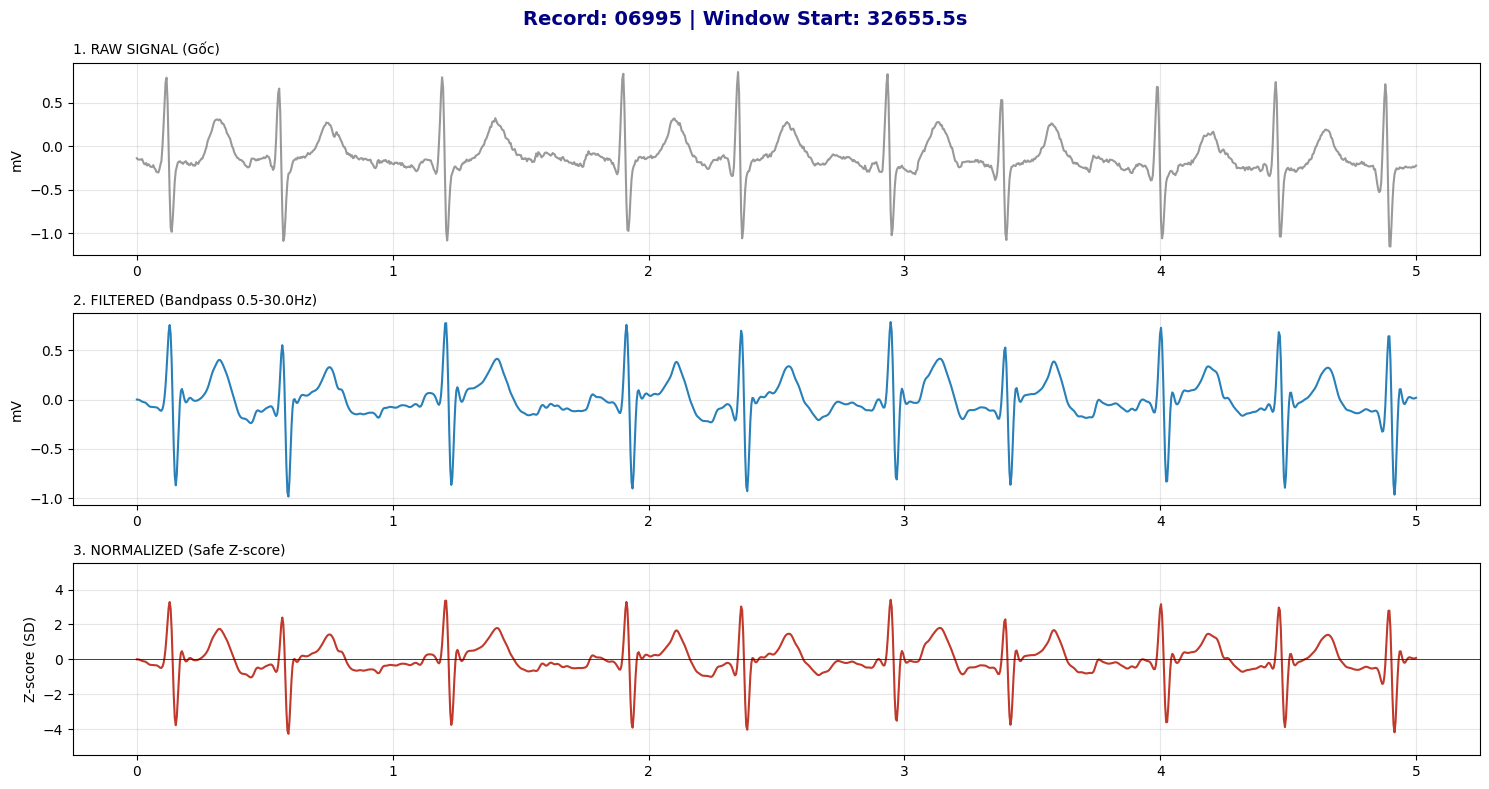

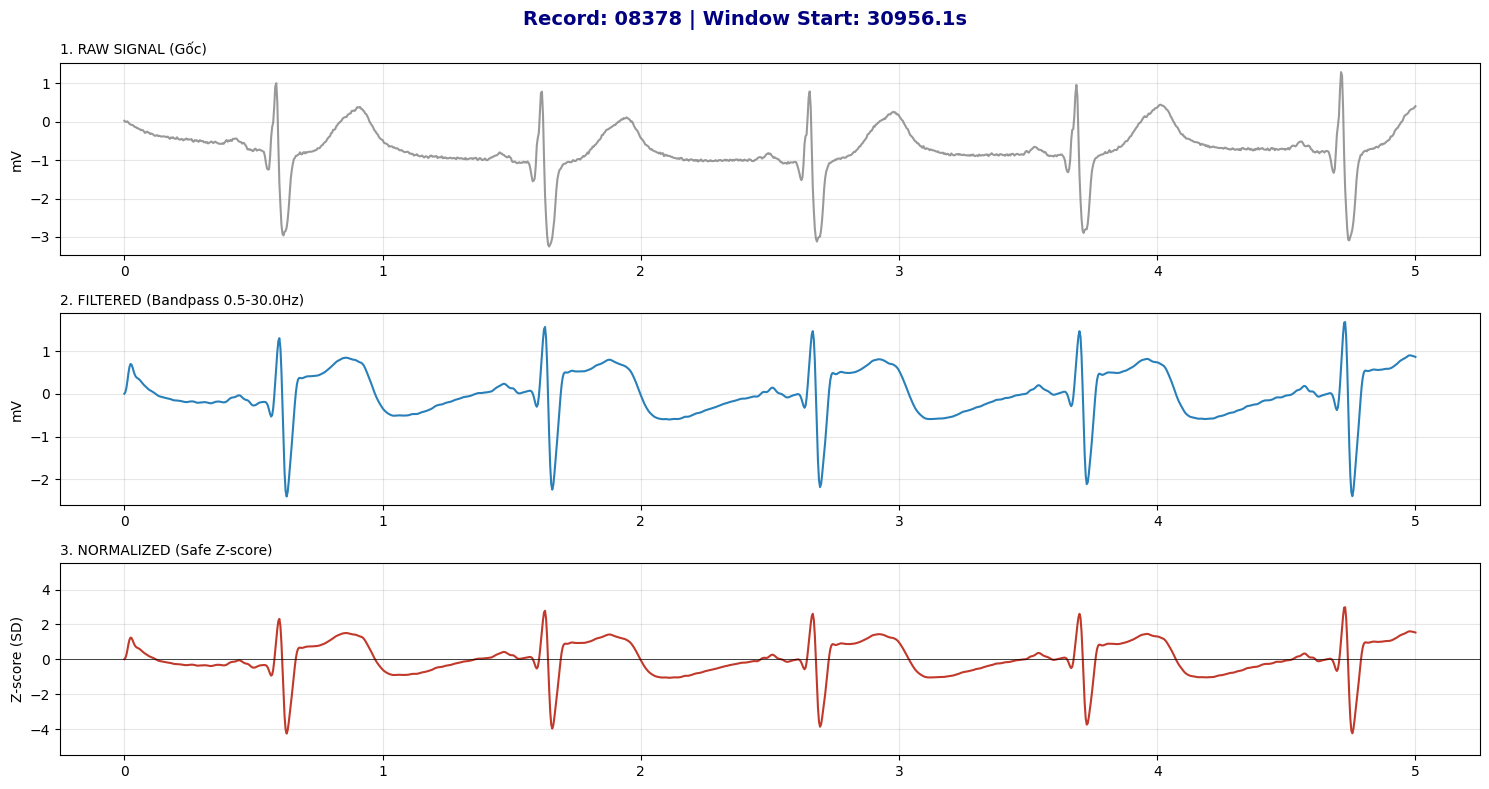

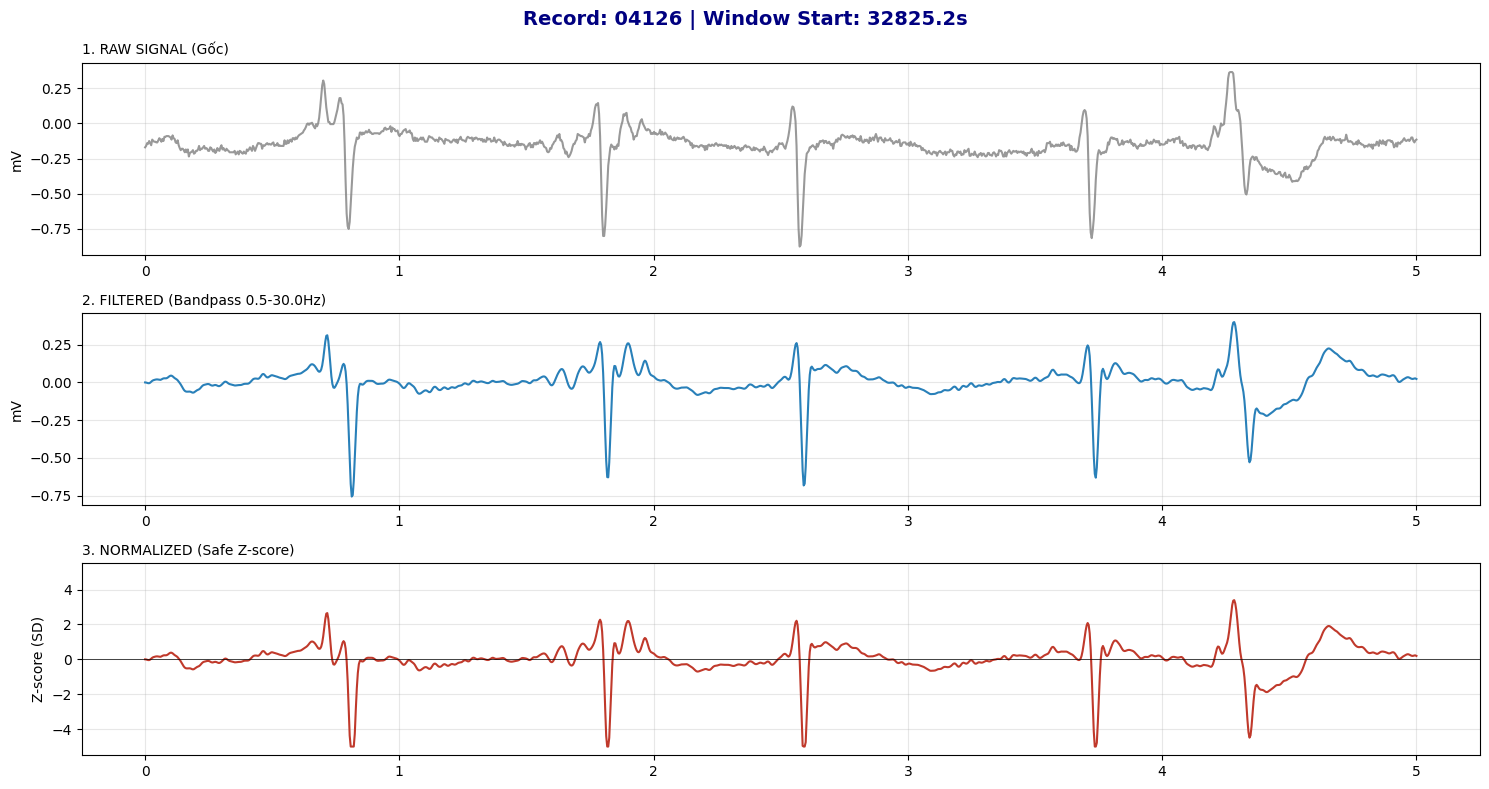

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import wfdb
import os
from scipy.signal import resample_poly, butter, sosfilt

# =============================================================================
# 1. ĐỊNH NGHĨA LẠI HÀM XỬ LÝ (ĐỂ CHẠY ĐỘC LẬP TRONG CELL NÀY)
# =============================================================================
# Copy y nguyên logic bạn đang dùng để đảm bảo tính nhất quán
TARGET_FS = 250
LOW_CUT = 0.5
HIGH_CUT = 30.0
FILTER_ORDER = 4

def debug_preprocess_pipeline(raw_sig, fs):
    # Bước 1: Resample
    if fs != TARGET_FS:
        gcd_fs = np.gcd(int(fs), int(TARGET_FS))
        up = int(TARGET_FS // gcd_fs)
        down = int(fs // gcd_fs)
        sig_resampled = resample_poly(raw_sig, up, down)
    else:
        sig_resampled = raw_sig.copy()

    # Bước 2: Filter
    sig_centered = sig_resampled - np.mean(sig_resampled)
    
    nyquist = 0.5 * TARGET_FS
    low = LOW_CUT / nyquist
    high = HIGH_CUT / nyquist
    sos = butter(FILTER_ORDER, [low, high], btype='band', output='sos')
    sig_filtered = sosfilt(sos, sig_centered)
    
    # Bước 3: Normalize (Safe Z-score)
    seg_std = np.std(sig_filtered)
    noise_floor = 0.05
    divisor = max(seg_std, noise_floor)
    sig_norm = sig_filtered / divisor
    sig_norm = np.clip(sig_norm, -5.0, 5.0)
    
    return sig_resampled, sig_filtered, sig_norm

# =============================================================================
# 2. HÀM VẼ SO SÁNH TRỰC QUAN
# =============================================================================
def inspect_signal_quality(db_dir, num_checks=3):
    print(f"\n🔍 ĐANG KIỂM TRA CHẤT LƯỢNG TÍN HIỆU TẠI: {db_dir}")
    
    # Lấy danh sách file
    records = [f.replace('.hea', '') for f in os.listdir(db_dir) if f.endswith('.hea')]
    # Loại bỏ file lỗi nếu có
    records = [r for r in records if r not in ['00735', '03665']]
    
    # Chọn ngẫu nhiên record
    selected_recs = np.random.choice(records, num_checks, replace=False)
    
    for rec in selected_recs:
        try:
            path = os.path.join(db_dir, rec)
            record = wfdb.rdrecord(path, channels=[0]) # Kênh 0
            
            # Chọn ngẫu nhiên một cửa sổ 5 giây để soi
            duration_sec = 5
            fs = record.fs
            start_idx = np.random.randint(0, len(record.p_signal) - duration_sec*fs)
            end_idx = start_idx + duration_sec*fs
            
            raw_segment = record.p_signal[start_idx:end_idx, 0]
            
            # Chạy qua pipeline
            sig_res, sig_filt, sig_norm = debug_preprocess_pipeline(raw_segment, fs)
            
            # --- VẼ ĐỒ THỊ ---
            fig, ax = plt.subplots(3, 1, figsize=(15, 8), sharex=False)
            fig.suptitle(f'Record: {rec} | Window Start: {start_idx/fs:.1f}s', fontsize=14, fontweight='bold', color='navy')
            
            # 1. Raw Signal
            t_raw = np.linspace(0, duration_sec, len(raw_segment))
            ax[0].plot(t_raw, raw_segment, color='gray', alpha=0.8)
            ax[0].set_title("1. RAW SIGNAL (Gốc)", loc='left', fontsize=10)
            ax[0].set_ylabel("mV")
            ax[0].grid(True, alpha=0.3)
            
            # 2. Filtered
            t_new = np.linspace(0, duration_sec, len(sig_filt))
            ax[1].plot(t_new, sig_filt, color='#2980b9')
            ax[1].set_title(f"2. FILTERED (Bandpass {LOW_CUT}-{HIGH_CUT}Hz)", loc='left', fontsize=10)
            ax[1].set_ylabel("mV")
            ax[1].grid(True, alpha=0.3)
            
            # 3. Normalized
            ax[2].plot(t_new, sig_norm, color='#c0392b')
            ax[2].set_title("3. NORMALIZED (Safe Z-score)", loc='left', fontsize=10)
            ax[2].set_ylabel("Z-score (SD)")
            ax[2].set_ylim(-5.5, 5.5) # Giới hạn hiển thị đúng như clip
            ax[2].grid(True, alpha=0.3)
            ax[2].axhline(y=0, color='black', linewidth=0.5)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Lỗi khi đọc {rec}: {e}")

# --- CHẠY KIỂM TRA ---
# Đảm bảo biến AFDB_DIR trỏ đúng thư mục file gốc của bạn
if 'AFDB_DIR' not in globals():
    AFDB_DIR = r"C:\Users\ADMIN\Documents\DANG_KHOA\dataset\files" # Cập nhật lại nếu cần

inspect_signal_quality(AFDB_DIR, num_checks=3)